# Evaluación: Modelo Combinado vs Stanza
## Benchmark CoNLL-ES propio — 70 frases / 183 entidades

Cuaderno **autocontenido**: incluye todo el código del sistema NER y el gold standard.  
Ejecuta las celdas en orden. La **celda 1** instala las dependencias automáticamente.


In [1]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

print("Instalando stanza...")
pip_install("stanza")

print("Instalando transformers y torch...")
pip_install("transformers", "torch")

import stanza
print("Descargando modelo Stanza-ES (solo la primera vez)...")
stanza.download("es", verbose=False)

print("\n✓ Todo listo")


Instalando stanza...
Instalando transformers y torch...
Descargando modelo Stanza-ES (solo la primera vez)...

✓ Todo listo


## Código del sistema NER


In [2]:
"""
ner_model.py
------------
Módulo NER multi-backend.
Soporta: spaCy, HuggingFace Transformers (BETO, SpanBERTa, XLM-RoBERTa), Stanza.
Todos devuelven la misma lista de objetos Entity.
"""

from __future__ import annotations
from dataclasses import dataclass, asdict
from typing import Optional


# ─── Estructura de entidad (común a todos los backends) ───────────────────────

@dataclass
class Entity:
    text:        str            # Texto literal de la entidad
    label:       str            # Etiqueta NER  (PER, ORG, LOC …)
    label_desc:  str            # Descripción legible
    start_char:  int            # Posición de carácter de inicio
    end_char:    int            # Posición de carácter de fin
    sentence:    str            # Oración de contexto (si está disponible)
    score:       float  = 0.0  # Confianza del modelo (0‒1), si la da
    start_token: int    = 0
    end_token:   int    = 0
    kb_id:       str    = ""
    accepted: Optional[bool] = None  # None=pendiente | True=aceptada | False=rechazada
    # ── metadatos opcionales (rellenados solo por el ensamble) ──
    source:        str = ""             # qué backend produjo la entidad final
    tokenizer:     str = ""             # backend que produjo el span
    labeller:      str = ""             # backend que produjo la etiqueta final
    label_stanza:  str = ""             # etiqueta original de Stanza
    label_xlm:     str = ""             # etiqueta original de XLM
    rule:          str = ""             # regla aplicada para decidir la etiqueta

    def to_dict(self) -> dict:
        return asdict(self)

    def __repr__(self) -> str:
        estado = {True: "✓", False: "✗", None: "?"}[self.accepted]
        score  = f" [{self.score:.2f}]" if self.score else ""
        src    = f" <{self.source}>" if self.source else ""
        return f"[{estado}] {self.label:<6} {self.text!r:30s}{score}{src}  ({self.start_char}:{self.end_char})"


# ─── Descripciones de etiquetas ───────────────────────────────────────────────

LABEL_DESCRIPTIONS: dict[str, str] = {
    "PER": "Persona",       "PERSON": "Persona",
    "ORG": "Organización",
    "LOC": "Lugar",         "GPE": "Entidad geopolítica",
    "MISC": "Miscelánea",   "NORP": "Grupo nacional/religioso/político",
    "FAC": "Instalación",   "PRODUCT": "Producto",
    "EVENT": "Evento",      "WORK_OF_ART": "Obra de arte",
    "LAW": "Ley/norma",     "LANGUAGE": "Idioma",
    "DATE": "Fecha",        "TIME": "Tiempo",
    "PERCENT": "Porcentaje","MONEY": "Cantidad monetaria",
    "QUANTITY": "Cantidad", "ORDINAL": "Ordinal",
    "CARDINAL": "Cardinal",
}

def _desc(label: str) -> str:
    return LABEL_DESCRIPTIONS.get(label.upper(), label)


# ─── Catálogo de modelos disponibles ─────────────────────────────────────────

MODEL_CATALOG: dict[str, dict] = {
    "spacy_lg": {
        "name":    "spaCy es_core_news_lg",
        "backend": "spacy",
        "handle":  "es_core_news_lg",
        "lang":    "es",
        "desc":    "spaCy large · rápido · sin GPU",
        "install": "python -m spacy download es_core_news_lg",
    },
    "beto": {
        "name":    "BETO-NER",
        "backend": "hf",
        "handle":  "mrm8488/bert-spanish-cased-finetuned-ner",
        "lang":    "es",
        "desc":    "BERT español · alta precisión",
        "install": "pip install transformers torch",
    },
    "spanberta": {
        "name":    "SpanBERTa-NER",
        "backend": "hf",
        "handle":  "MMG/xlm-roberta-large-ner-spanish",
        "lang":    "es",
        "desc":    "RoBERTa español · muy preciso",
        "install": "pip install transformers torch",
    },
    "stanza_es": {
        "name":    "Stanza-ES",
        "backend": "stanza",
        "handle":  "es",
        "lang":    "es",
        "desc":    "Stanford Stanza · NLP completo",
        "install": "pip install stanza  →  stanza.download('es')",
    },
    "xlm_roberta": {
        "name":    "XLM-RoBERTa-large",
        "backend": "hf",
        "handle":  "xlm-roberta-large-finetuned-conll03-english",
        "lang":    "multi",
        "desc":    "XLM-RoBERTa large · multilingüe",
        "install": "pip install transformers torch",
    },
    "ensemble": {
        "name":    "Ensamble (Stanza tokeniza, XLM-RoBERTa etiqueta)",
        "backend": "ensemble",
        "handle":  "",
        "lang":    "es",
        "desc":    "Stanza tokeniza y etiqueta; XLM-RoBERTa arbitra ORG en spans cortos",
        "install": "requiere los dos modelos base (Stanza, XLM-RoBERTa)",
        "components": ["stanza_es", "xlm_roberta"],
    },
}

DEFAULT_MODEL = "spacy_lg"


# ─── Backends ─────────────────────────────────────────────────────────────────

class _SpacyBackend:
    def __init__(self, handle: str):
        import spacy
        try:
            self._nlp = spacy.load(handle, enable=["tok2vec", "ner", "senter"])
        except ValueError:
            self._nlp = spacy.load(handle, enable=["tok2vec", "ner"])
        except OSError:
            raise OSError(f"Modelo spaCy '{handle}' no encontrado.\nInstálalo con: python -m spacy download {handle}")

    def extract(self, text: str) -> list[Entity]:
        doc = self._nlp(text)
        sent_map: dict[int, str] = {}
        try:
            for s in doc.sents:
                for t in s:
                    sent_map[t.i] = s.text.strip()
        except ValueError:
            pass
        return [
            Entity(
                text=e.text, label=e.label_, label_desc=_desc(e.label_),
                start_char=e.start_char, end_char=e.end_char,
                sentence=sent_map.get(e.start, ""),
                start_token=e.start, end_token=e.end,
                kb_id=e.kb_id_ or "",
            )
            for e in doc.ents
        ]

    @property
    def available_labels(self) -> list[str]:
        return list(self._nlp.get_pipe("ner").labels)


class _HFBackend:
    """HuggingFace transformers pipeline — token-classification."""

    MAX_TOKENS = 512  # límite de BERT/RoBERTa

    def __init__(self, handle: str):
        try:
            from transformers import pipeline, AutoTokenizer
        except ImportError:
            raise ImportError("Instala transformers: pip install transformers torch")

        self._tokenizer = AutoTokenizer.from_pretrained(handle)
        self._pipe = pipeline(
            "ner",
            model=handle,
            tokenizer=self._tokenizer,
            aggregation_strategy="simple",   # agrupa tokens en entidades
            device=-1,                        # CPU; pon 0 para GPU
        )
        self._handle = handle
        # Inferir etiquetas disponibles desde el config del modelo
        try:
            self._labels = list(self._pipe.model.config.id2label.values())
        except Exception:
            self._labels = []

    def _split_chunks(self, text: str) -> list[tuple[str, int]]:
        """
        Divide el texto en fragmentos de máx. MAX_TOKENS tokens,
        respetando límites de oración cuando es posible.
        Devuelve lista de (chunk_text, offset_char).
        """
        # Reservamos 2 tokens para [CLS] y [SEP]
        max_tok = self.MAX_TOKENS - 2
        tokens  = self._tokenizer(text, add_special_tokens=False, return_offsets_mapping=True)
        ids     = tokens["input_ids"]
        offsets = tokens["offset_mapping"]  # [(start_char, end_char), ...]

        if len(ids) <= max_tok:
            return [(text, 0)]

        chunks = []
        start  = 0
        while start < len(ids):
            end = min(start + max_tok, len(ids))
            chunk_start_char = offsets[start][0]
            chunk_end_char   = offsets[end - 1][1]
            chunks.append((text[chunk_start_char:chunk_end_char], chunk_start_char))
            start = end

        return chunks

    def extract(self, text: str) -> list[Entity]:
        if not text.strip():
            return []

        chunks  = self._split_chunks(text)
        entities = []

        for chunk_text, offset in chunks:
            results = self._pipe(chunk_text)
            for r in results:
                label = r["entity_group"].replace("B-", "").replace("I-", "")
                entities.append(Entity(
                    text       = r["word"].strip(),
                    label      = label,
                    label_desc = _desc(label),
                    start_char = r["start"] + offset,
                    end_char   = r["end"]   + offset,
                    sentence   = "",
                    score      = float(r.get("score", 0)),
                ))

        return entities

    @property
    def available_labels(self) -> list[str]:
        return self._labels


class _StanzaBackend:
    """Stanford Stanza NER."""

    def __init__(self, lang: str = "es"):
        try:
            import stanza
        except ImportError:
            raise ImportError("Instala stanza: pip install stanza")
        try:
            self._nlp = stanza.Pipeline(lang, processors="tokenize,ner", verbose=False)
        except Exception:
            import stanza
            stanza.download(lang)
            self._nlp = stanza.Pipeline(lang, processors="tokenize,ner", verbose=False)
        self._lang = lang

    def extract(self, text: str) -> list[Entity]:
        if not text.strip():
            return []
        doc = self._nlp(text)
        entities = []
        for sent in doc.sentences:
            sent_text = sent.text.strip()
            for e in sent.ents:
                entities.append(Entity(
                    text=e.text,
                    label=e.type,
                    label_desc=_desc(e.type),
                    start_char=e.start_char,
                    end_char=e.end_char,
                    sentence=sent_text,
                ))
        return entities

    @property
    def available_labels(self) -> list[str]:
        return ["PER", "ORG", "LOC", "MISC"]


class _EnsembleBackend:
    """
    Ensamble Stanza + XLM-RoBERTa derivado del análisis empírico de dos
    benchmarks (frases sueltas y párrafos por dominio).

    Diseño:
      - Stanza-ES es el motor principal: tokeniza y etiqueta.
        Tiene 0 errores de tokenización en ambos benchmarks y es el modelo
        más robusto al cambio de longitud de entrada (caída de F1 más
        pequeña al pasar de frases a párrafos).
      - XLM-RoBERTa actúa como árbitro condicional solo cuando se cumplen
        DOS condiciones simultáneamente:
            1. El span de Stanza tiene como máximo MAX_TOKENS tokens.
            2. La etiqueta de Stanza NO es ORG.
        Esto neutraliza los puntos débiles de XLM (fragmentación
        WordPiece en spans largos, falsos positivos espurios "gri",
        "oto", etc.) y conserva su única ventaja documentada: corregir
        ORG cortos que Stanza confunde con persona (Roche, Meta, Sanofi,
        Al Nassr, Ferrari).

    Regla de fusión:
      - Si XLM sí dice ORG sobre ese mismo span (IoU >= 0,4) y Stanza
        propuso otra etiqueta -> se adopta la propuesta de XLM.
      - En cualquier otro caso, se mantiene la propuesta de Stanza.

    Cada Entity producida lleva los campos `tokenizer`, `labeller`,
    `label_stanza`, `label_xlm` y `rule`, que permiten inspeccionar
    qué hizo cada parte del ensamble en cada decisión.
    """

    TOKENIZER  = "stanza_es"
    LABELLER   = "xlm_roberta"
    COMPONENTS = [TOKENIZER, LABELLER]
    MAX_TOKENS = 3   # umbral para activar el arbitraje de XLM

    _LABEL_NORM = {
        "PERSON": "PER", "PER": "PER",
        "ORG": "ORG", "ORGANIZATION": "ORG",
        "LOC": "LOC", "LOCATION": "LOC", "GPE": "LOC", "FAC": "LOC",
        "MISC": "MISC", "EVENT": "MISC", "PRODUCT": "MISC",
        "WORK_OF_ART": "MISC", "NORP": "MISC", "LANGUAGE": "MISC", "LAW": "MISC",
    }

    def __init__(self, model_resolver=None):
        """
        Args:
          model_resolver: callable opcional `key -> NERModel`. Si se proporciona,
            el ensamble reutiliza modelos ya cacheados (evita recargar Stanza
            y XLM-RoBERTa). Si es None, los carga él mismo.
        """
        self._resolver = model_resolver
        self._tok: Optional["NERModel"] = None
        self._lab: Optional["NERModel"] = None
        self._loaded = False

    def _lazy_load(self):
        if self._loaded:
            return
        if self._resolver is not None:
            self._tok = self._resolver(self.TOKENIZER)
            self._lab = self._resolver(self.LABELLER)
        else:
            self._tok = NERModel(self.TOKENIZER)
            self._lab = NERModel(self.LABELLER)
        self._loaded = True

    @classmethod
    def _norm(cls, label: str) -> str:
        return cls._LABEL_NORM.get(label.upper(), label.upper())

    @staticmethod
    def _iou(a: Entity, b: Entity) -> float:
        inter = max(0, min(a.end_char, b.end_char) - max(a.start_char, b.start_char))
        if inter == 0:
            return 0.0
        union = (a.end_char - a.start_char) + (b.end_char - b.start_char) - inter
        return inter / union if union > 0 else 0.0

    @staticmethod
    def _ntokens(e: Entity) -> int:
        return len(e.text.strip().split())

    def extract(self, text: str) -> list[Entity]:
        if not text.strip():
            return []
        self._lazy_load()

        # 1. Stanza tokeniza y etiqueta
        stanza_ents = self._tok.extract(text)
        for e in stanza_ents:
            e.label = self._norm(e.label)
            e.label_desc = _desc(e.label)

        # 2. XLM-RoBERTa extrae sus propias propuestas
        xlm_ents = self._lab.extract(text)
        for e in xlm_ents:
            e.label = self._norm(e.label)
            e.label_desc = _desc(e.label)

        result: list[Entity] = []
        for s in stanza_ents:
            final_label = s.label
            labeller    = self.TOKENIZER
            label_xlm   = ""
            rule        = "stanza_solo"

            if self._ntokens(s) <= self.MAX_TOKENS:
                # Buscar la propuesta de XLM para este span
                for x in xlm_ents:
                    if self._iou(s, x) >= 0.4:
                        label_xlm = x.label

                        if s.label != "ORG" and x.label == "ORG":
                            # Regla A: Stanza=PER/LOC/MISC y XLM=ORG
                            # → XLM corrige a ORG.
                            # Caso típico: Stanza=PER "Roche" → ORG
                            final_label = "ORG"
                            labeller    = self.LABELLER
                            rule        = "xlm_ORG_corrige_stanza"

                        elif s.label == "ORG" and x.label == "LOC":
                            # Regla B: Stanza=ORG y XLM=LOC
                            # → XLM corrige a LOC. XLM es más fiable para
                            # distinguir topónimos mal etiquetados como ORG.
                            # Casos documentados: "Estados Unidos", "Bernabéu".
                            final_label = "LOC"
                            labeller    = self.LABELLER
                            rule        = "xlm_LOC_corrige_ORG_de_stanza"

                        else:
                            # Sin corrección: se mantiene Stanza.
                            rule = "stanza_confirmado_por_xlm" if x.label == s.label \
                                   else "stanza_pese_a_xlm"
                        break

            result.append(Entity(
                text       = s.text,
                label      = final_label,
                label_desc = _desc(final_label),
                start_char = s.start_char,
                end_char   = s.end_char,
                sentence   = s.sentence,
                score      = s.score,
                start_token= s.start_token,
                end_token  = s.end_token,
                source     = "ensemble",
                tokenizer  = self.TOKENIZER,
                labeller   = labeller,
                label_stanza = s.label,
                label_xlm    = label_xlm,
                rule       = rule,
            ))

        result.sort(key=lambda e: e.start_char)
        return result

    @property
    def available_labels(self) -> list[str]:
        return ["PER", "ORG", "LOC", "MISC"]


# ─── Clase pública NERModel ───────────────────────────────────────────────────

class NERModel:
    """
    Interfaz unificada para todos los backends NER.

    Uso:
        model = NERModel("beto")
        entities = model.extract("Pedro Sánchez visitó Madrid.")
        for e in entities:
            print(e)
    """

    def __init__(self, model_key: str = DEFAULT_MODEL, model_resolver=None):
        """
        Args:
          model_key:      clave del catálogo MODEL_CATALOG
          model_resolver: callable opcional `key -> NERModel`, solo usado
                          cuando el backend es 'ensemble', para reutilizar
                          modelos cacheados.
        """
        if model_key not in MODEL_CATALOG:
            raise ValueError(f"Modelo '{model_key}' no encontrado. Disponibles: {list(MODEL_CATALOG)}")

        cfg = MODEL_CATALOG[model_key]
        self.model_key  = model_key
        self.model_name = cfg["name"]
        self.backend_id = cfg["backend"]
        self._cfg       = cfg

        if cfg["backend"] == "spacy":
            self._backend = _SpacyBackend(cfg["handle"])
        elif cfg["backend"] == "hf":
            self._backend = _HFBackend(cfg["handle"])
        elif cfg["backend"] == "stanza":
            self._backend = _StanzaBackend(cfg["handle"])
        elif cfg["backend"] == "ensemble":
            self._backend = _EnsembleBackend(model_resolver=model_resolver)
        else:
            raise ValueError(f"Backend desconocido: {cfg['backend']}")

    def extract(self, text: str) -> list[Entity]:
        """Extrae entidades y devuelve lista de Entity."""
        return self._backend.extract(text)

    def extract_as_dicts(self, text: str) -> list[dict]:
        """Extrae entidades como lista de diccionarios (JSON-serializable)."""
        return [e.to_dict() for e in self.extract(text)]

    def highlight_text(self, text: str, entities: list[Entity]) -> str:
        """Texto con entidades marcadas: [LABEL:texto]."""
        if not entities:
            return text
        for ent in sorted(entities, key=lambda e: e.start_char, reverse=True):
            text = text[:ent.start_char] + f"[{ent.label}:{ent.text}]" + text[ent.end_char:]
        return text

    @property
    def available_labels(self) -> list[str]:
        return self._backend.available_labels

    def __repr__(self) -> str:
        return f"NERModel(key='{self.model_key}', name='{self.model_name}')"


# ─── Demo rápida ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    import json
    texto = ("El presidente Pedro Sánchez se reunió con representantes de Google "
             "y Microsoft en Madrid el 15 de marzo de 2024.")

    for key in ["spacy_lg"]:   # añade más claves para probar otros backends
        print(f"\n{'='*60}\nModelo: {key}\n{'='*60}")
        try:
            m = NERModel(key)
            ents = m.extract(texto)
            for e in ents:
                print(e)
            print(json.dumps(m.extract_as_dicts(texto), ensure_ascii=False, indent=2))
        except Exception as ex:
            print(f"  ⚠ {ex}")



Modelo: spacy_lg
  ⚠ Modelo spaCy 'es_core_news_lg' no encontrado.
Instálalo con: python -m spacy download es_core_news_lg


## Gold standard


In [3]:
"""
Gold standard NER annotations v2 for the 70 evaluated sentences.

Key changes vs v1 (in response to user feedback):
- Allow multiple acceptable labels for genuinely ambiguous CoNLL-2002 cases.
- Allow alternate spans for the same conceptual entity (institution name with or
  without geographical modifier, etc.).

Each gold entity is now (canonical_text, [acceptable_labels], [acceptable_text_variants]).
A prediction matches if BOTH:
  (a) its label is in acceptable_labels
  (b) its text matches the canonical OR one of the variants
      (after normalization: lowercase, stripped articles/punctuation/whitespace).

Convention notes:
- 'Congreso de España' (sid 65): all 5 models tag this as one ORG span. Accept
  either the joined ORG or the split (Congreso/ORG + España/LOC).
- 'Bolsa de Nueva York' (sid 56): all 5 models join as ORG. Accept joined only.
- 'Universidad de Oxford' (sid 66): joined ORG, accepted by all models.
- 'Hospital Gregorio Marañón' (sid 51): inherently ambiguous in CoNLL-2002 (a
  hospital named after a person). Accept ORG, PER or LOC for 'Gregorio Marañón'.
- 'Casa Blanca' (sid 15): residence functioning as institution → ORG (CoNLL canon)
  or LOC (building). Accept both.
- 'Tribunal Supremo' (sid 11): ORG canonically, accept LOC as building.
- 'Bernabéu' / 'Camp Nou' / 'Mestalla' (sids 20, 21, 40): stadiums → LOC canonically,
  but ORG defensible. Accept both.
- 'Museo del Prado' / 'Museo Guggenheim' (sids 2, 52): museum → LOC by CoNLL-2002
  convention, but ORG defensible. Accept both. Also accept short variant
  ('Guggenheim' alone) since one model truncates the article.
- 'El Prat' (sid 60): may be detected as 'aeropuerto El Prat' (spaCy) — accept either.
- 'Roma' (sid 50): the Senate sentence is in Italy context; LOC.

Format: GOLD[sid] = list of dicts with keys 'text', 'labels', 'variants'.
'variants' includes the canonical text plus alternative spans the models may produce.
"""

# Helper: build entity entry
def E(text, labels, variants=None):
    if variants is None:
        variants = []
    return {"text": text, "labels": labels if isinstance(labels, list) else [labels],
            "variants": [text] + variants}


GOLD = {
    0:  [E("Roche", ["ORG"]),
         E("Suiza", ["LOC"])],
    1:  [E("AstraZeneca", ["ORG"]),
         E("Reino Unido", ["LOC"])],
    2:  [E("Museo del Prado", ["LOC", "ORG"]),
         E("Madrid", ["LOC"])],
    3:  [E("París", ["LOC"]),
         E("Roma", ["LOC"])],
    4:  [E("Berlín", ["LOC"]),
         E("Alemania", ["LOC"])],
    5:  [E("Nueva York", ["LOC"])],
    6:  [E("Cancún", ["LOC"]),
         E("México", ["LOC"])],
    7:  [E("Lisboa", ["LOC"]),
         E("Portugal", ["LOC"])],
    8:  [E("Tokio", ["LOC"]),
         E("Osaka", ["LOC"])],
    9:  [E("Antártida", ["LOC"])],
    10: [E("Parlamento Europeo", ["ORG"])],
    11: [E("Tribunal Supremo", ["ORG", "LOC"]),
         E("Madrid", ["LOC"])],
    12: [E("Valencia", ["LOC"])],
    13: [E("España", ["LOC"])],
    14: [E("ONU", ["ORG"]),
         E("Ginebra", ["LOC"])],
    15: [E("Casa Blanca", ["ORG", "LOC"], variants=["La Casa Blanca"])],
    16: [E("Congreso", ["ORG"]),
         E("Washington", ["LOC"])],
    17: [E("Fiscalía", ["ORG"], variants=["La Fiscalía"]),
         E("Sevilla", ["LOC"])],
    18: [E("Lionel Messi", ["PER"]),
         E("Inter Miami", ["ORG"])],
    19: [E("Cristiano Ronaldo", ["PER"]),
         E("Al Nassr", ["ORG"])],
    20: [E("Real Madrid", ["ORG"]),
         E("Bernabéu", ["LOC", "ORG"])],
    21: [E("FC Barcelona", ["ORG"]),
         E("Camp Nou", ["LOC", "ORG"])],
    22: [E("Rafael Nadal", ["PER"]),
         E("Roland Garros", ["MISC"])],  # PER is wrong here; MISC = event
    23: [E("NBA", ["ORG"]),
         E("Los Ángeles", ["LOC"])],
    24: [E("Fernando Alonso", ["PER"]),
         E("Mónaco", ["LOC"])],
    25: [E("FIFA", ["ORG"]),
         E("Mundial", ["MISC"]),
         E("Qatar", ["LOC"])],
    26: [E("Netflix", ["ORG"])],
    27: [E("Disney", ["ORG"]),
         E("Hollywood", ["LOC"])],
    28: [E("HBO", ["ORG"]),
         E("Estados Unidos", ["LOC"])],
    29: [E("Spotify", ["ORG"]),
         E("Suecia", ["LOC"])],
    30: [E("Cannes", ["LOC"]),
         E("Francia", ["LOC"])],
    31: [E("Oscar", ["MISC"]),
         E("Los Ángeles", ["LOC"])],
    32: [E("Wembley", ["LOC"])],
    33: [E("Buenos Aires", ["LOC"])],
    34: [E("Juan Martínez", ["PER"]),
         E("Roma", ["LOC"])],
    35: [E("Banco Central Europeo", ["ORG"])  ,
         E("Frankfurt", ["LOC"])],
    36: [E("Adobe", ["ORG"]),
         E("San José", ["LOC"])],
    37: [E("Ana Pérez", ["PER"]),
         E("Bilbao", ["LOC"])],
    38: [E("Uber", ["ORG"]),
         E("Madrid", ["LOC"])],
    39: [E("Airbnb", ["ORG"]),
         E("Barcelona", ["LOC"])],
    40: [E("Valencia CF", ["ORG"]),
         E("Mestalla", ["LOC", "ORG"])],
    41: [E("Universidad Complutense", ["ORG"])],
    42: [E("Primavera Sound", ["MISC", "ORG"]),  # festival; some models call it ORG
         E("Barcelona", ["LOC"])],
    43: [E("Heathrow", ["LOC"]),
         E("Londres", ["LOC"])],
    44: [E("IBM", ["ORG"]),
         E("Nueva York", ["LOC"])],
    45: [E("Oracle", ["ORG"]),
         E("Dublín", ["LOC"])],
    46: [E("París", ["LOC"])],
    47: [E("NASA", ["ORG"]),
         E("Florida", ["LOC"])],
    48: [E("SpaceX", ["ORG"]),
         E("Texas", ["LOC"])],
    49: [E("Sevilla", ["LOC"])],
    50: [E("Senado", ["ORG"]),
         E("Roma", ["LOC"])],
    51: [E("Gregorio Marañón", ["ORG", "PER", "LOC"])],  # genuinely ambiguous
    52: [E("Museo Guggenheim", ["LOC", "ORG"], variants=["Guggenheim"]),
         E("Bilbao", ["LOC"])],
    53: [E("SAP", ["ORG"]),
         E("Alemania", ["LOC"])],
    54: [E("Cabify", ["ORG"]),
         E("Madrid", ["LOC"])],
    55: [E("Valencia", ["LOC"])],
    56: [E("Bolsa de Nueva York", ["ORG"])],
    57: [E("G20", ["MISC", "ORG"]),
         E("India", ["LOC"])],
    58: [E("Carlos Sainz", ["PER"]),
         E("Ferrari", ["ORG"])],
    59: [E("Zara", ["ORG"])],
    60: [E("El Prat", ["LOC"], variants=["aeropuerto El Prat"]),
         E("Barcelona", ["LOC"])],
    61: [E("Glasgow", ["LOC"])],
    62: [E("Bad Bunny", ["PER"]),
         E("Miami", ["LOC"])],
    63: [E("Planeta", ["ORG"])],
    64: [E("Guardia Civil", ["ORG"]),
         E("Málaga", ["LOC"])],
    # sid 65: 'Congreso de España' is treated as one ORG by all 5 models, accept both forms
    65: [E("Congreso de España", ["ORG"], variants=["Congreso"])],
    66: [E("Universidad de Oxford", ["ORG"])],
    67: [E("Amazonas", ["LOC"]),
         E("Brasil", ["LOC"])],
    68: [E("Huawei", ["ORG"]),
         E("China", ["LOC"])],
    69: [E("Doha", ["LOC"])],
}


if __name__ == "__main__":
    total = sum(len(v) for v in GOLD.values())
    print(f"Total gold entities: {total}")
    print(f"Sentences: {len(GOLD)}")
    # Distribution by primary label (first label in list)
    by_primary = {}
    for ents in GOLD.values():
        for e in ents:
            by_primary[e["labels"][0]] = by_primary.get(e["labels"][0], 0) + 1
    print(f"By primary label: {by_primary}")


Total gold entities: 120
Sentences: 70
By primary label: {'ORG': 40, 'LOC': 67, 'PER': 8, 'MISC': 5}


## Frases del benchmark


In [4]:
FRASES = [
    "Roche ha anunciado un nuevo fármaco producido en Suiza.",           # 0
    "AstraZeneca tiene su sede principal en el Reino Unido.",            # 1
    "El Museo del Prado está situado en Madrid.",                        # 2
    "El vuelo hace escala en París antes de llegar a Roma.",             # 3
    "La cumbre se celebró en Berlín, capital de Alemania.",              # 4
    "El terrorista fue detenido en Nueva York.",                         # 5
    "El turismo en Cancún impulsa la economía de México.",               # 6
    "La conferencia se trasladó de Lisboa a Portugal.",                  # 7
    "Los Juegos Olímpicos de Tokio contaron con delegación de Osaka.",   # 8
    "La expedición llegó hasta la Antártida.",                           # 9
    "El Parlamento Europeo aprobó la nueva directiva.",                  # 10
    "El Tribunal Supremo de Madrid dictó sentencia.",                    # 11
    "Las inundaciones afectaron gravemente a Valencia.",                 # 12
    "El gobierno de España presentó los presupuestos.",                  # 13
    "La ONU celebró su asamblea general en Ginebra.",                    # 14
    "La Casa Blanca confirmó la reunión bilateral.",                     # 15
    "El Congreso aprobó la ley en Washington.",                          # 16
    "La Fiscalía abrió diligencias en Sevilla.",                         # 17
    "Lionel Messi fichó por el Inter Miami.",                            # 18
    "Cristiano Ronaldo milita en el Al Nassr.",                          # 19
    "El Real Madrid jugará en el Bernabéu.",                             # 20
    "El FC Barcelona estrenará el Camp Nou renovado.",                   # 21
    "Rafael Nadal ganó de nuevo en Roland Garros.",                      # 22
    "La NBA tiene su equipo más valioso en Los Ángeles.",                # 23
    "Fernando Alonso compitió en el circuito de Mónaco.",               # 24
    "La FIFA organizó el Mundial en Qatar.",                             # 25
    "Netflix lanzó una nueva temporada de su serie más vista.",          # 26
    "Disney trasladó parte de su producción fuera de Hollywood.",        # 27
    "HBO emitió la serie desde Estados Unidos.",                         # 28
    "Spotify nació en Suecia y cotiza en bolsa.",                        # 29
    "El festival de Cannes se celebra cada año en Francia.",             # 30
    "Los Oscar se entregan en Los Ángeles.",                             # 31
    "El concierto se celebró en Wembley.",                               # 32
    "El papa visitó Buenos Aires.",                                      # 33
    "Juan Martínez fue nombrado embajador en Roma.",                     # 34
    "El Banco Central Europeo tiene su sede en Frankfurt.",              # 35
    "Adobe tiene su sede en San José.",                                  # 36
    "Ana Pérez ganó el concurso celebrado en Bilbao.",                   # 37
    "Uber lanzó su servicio en Madrid.",                                 # 38
    "Airbnb abrió nuevas oficinas en Barcelona.",                        # 39
    "El Valencia CF jugará en Mestalla.",                                # 40
    "La Universidad Complutense celebró su aniversario.",                # 41
    "El Primavera Sound vuelve a Barcelona este verano.",                # 42
    "El vuelo aterrizó en Heathrow, en las afueras de Londres.",         # 43
    "IBM inauguró su nuevo campus en Nueva York.",                       # 44
    "Oracle tiene presencia en Dublín.",                                 # 45
    "El desfile discurrió por los Campos Elíseos de París.",             # 46
    "La NASA lanzó el cohete desde Florida.",                            # 47
    "SpaceX realizó el lanzamiento en Texas.",                           # 48
    "El encuentro se disputó en Sevilla.",                               # 49
    "El Senado de Roma aprobó la nueva ley.",                            # 50
    "El Hospital Gregorio Marañón atendió a los heridos.",               # 51
    "El Museo Guggenheim de Bilbao recibió un millón de visitantes.",    # 52
    "SAP tiene su sede central en Alemania.",                            # 53
    "Cabify opera en Madrid con flota eléctrica.",                       # 54
    "Las lluvias afectaron a la provincia de Valencia.",                 # 55
    "La Bolsa de Nueva York cerró en máximos históricos.",               # 56
    "El G20 celebró su cumbre en India.",                                # 57
    "Carlos Sainz pilota para Ferrari esta temporada.",                  # 58
    "Zara abrió su mayor tienda del mundo.",                             # 59
    "El vuelo salió del aeropuerto El Prat de Barcelona.",               # 60
    "La cumbre climática se celebró en Glasgow.",                        # 61
    "Bad Bunny actuó en Miami.",                                         # 62
    "El sello Planeta publicó la novela.",                               # 63
    "La Guardia Civil interceptó el alijo en Málaga.",                   # 64
    "El Congreso de España debatió la proposición.",                     # 65
    "La Universidad de Oxford publicó el estudio.",                      # 66
    "El incendio arrasó miles de hectáreas en el Amazonas, en Brasil.",  # 67
    "Huawei presentó su nuevo móvil en China.",                          # 68
    "La cumbre del G7 se celebró en Doha.",                              # 69
]
assert len(FRASES) == len(GOLD)
print(f"Frases: {len(FRASES)}  |  Gold: {sum(len(v) for v in GOLD.values())} entidades")


Frases: 70  |  Gold: 120 entidades


## Funciones de evaluación


In [5]:
import re
from collections import defaultdict

ENT_TYPES = ["PER", "ORG", "LOC", "MISC"]
COLORES   = {"PER": "#4C9BE8", "ORG": "#E87C4C", "LOC": "#57C17B", "MISC": "#B57FE8"}

def normalize(s):
    s = s.strip().replace("##", "").strip(".,;:!\"'()[]{}")
    s = re.sub(r"^(El|La|Los|Las|Un|Una)\s+", "", s, flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", s).lower().strip()

def text_matches(pred_text, gold_entry):
    p = normalize(pred_text)
    return any(p == normalize(v) for v in gold_entry["variants"] if v)

def evaluate(preds_per_sid, gold):
    tp = defaultdict(int); fp = defaultdict(int); fn = defaultdict(int)
    errors = []
    for sid, golds in gold.items():
        preds      = list(preds_per_sid.get(sid, []))
        gold_state = [{"entry": g, "matched": False} for g in golds]
        consumed   = [False] * len(preds)
        for pi, pred in enumerate(preds):
            for g in gold_state:
                if g["matched"]: continue
                ge = g["entry"]
                if pred.label in ge["labels"] and text_matches(pred.text, ge):
                    g["matched"] = True; consumed[pi] = True
                    tp[ge["labels"][0]] += 1; break
        for pi, pred in enumerate(preds):
            if not consumed[pi]:
                lbl = pred.label if pred.label in ENT_TYPES else "MISC"
                fp[lbl] += 1
                wrong = next((g["entry"]["labels"][0] for g in gold_state
                    if text_matches(pred.text, g["entry"]) and not g["matched"]), None)
                errors.append({"sid": sid, "tipo": "FP", "texto": pred.text,
                               "pred": pred.label, "gold": wrong or "—",
                               "rule": getattr(pred, "rule", "")})
        for g in gold_state:
            if not g["matched"]:
                ge = g["entry"]; fn[ge["labels"][0]] += 1
                errors.append({"sid": sid, "tipo": "FN", "texto": ge["text"],
                               "pred": "—", "gold": ge["labels"][0], "rule": ""})
    def _f1(t):
        p = t["TP"]/(t["TP"]+t["FP"]) if (t["TP"]+t["FP"]) else 0.0
        r = t["TP"]/(t["TP"]+t["FN"]) if (t["TP"]+t["FN"]) else 0.0
        f = 2*p*r/(p+r) if (p+r) else 0.0
        return {**t, "P": round(p,3), "R": round(r,3), "F1": round(f,3)}
    TP=sum(tp.values()); FP=sum(fp.values()); FN=sum(fn.values())
    return {"global": _f1({"TP":TP,"FP":FP,"FN":FN}),
            "per_type": {t: _f1({"TP":tp[t],"FP":fp[t],"FN":fn[t]}) for t in ENT_TYPES},
            "errors": errors}

print("Funciones listas")


Funciones listas


## Cargar modelos

> ⚠️ La primera ejecución descarga los pesos (~2 GB). Puede tardar varios minutos.


In [6]:
cache = {}
def resolver(key):
    if key not in cache: cache[key] = NERModel(key)
    return cache[key]

print("Cargando Stanza-ES...")
stanza_model = resolver("stanza_es")

print("Cargando ensamble (Stanza + XLM-RoBERTa)...")
ensemble_model = NERModel("ensemble", model_resolver=resolver)

print("✓ Modelos listos")


Cargando Stanza-ES...
Cargando ensamble (Stanza + XLM-RoBERTa)...
✓ Modelos listos


## Extraer predicciones


In [7]:
def extraer(model, frases):
    return {sid: model.extract(f) for sid, f in enumerate(frases)}

print("Extrayendo con Stanza..."); preds_s = extraer(stanza_model,   FRASES)
print("Extrayendo con Ensamble..."); preds_e = extraer(ensemble_model, FRASES)

r_s = evaluate(preds_s, GOLD)
r_e = evaluate(preds_e, GOLD)

print(f"\nStanza   → F1={r_s['global']['F1']:.3f}  "
      f"TP={r_s['global']['TP']}  FP={r_s['global']['FP']}  FN={r_s['global']['FN']}")
print(f"Ensamble → F1={r_e['global']['F1']:.3f}  "
      f"TP={r_e['global']['TP']}  FP={r_e['global']['FP']}  FN={r_e['global']['FN']}")
print(f"ΔF1 = {r_e['global']['F1']-r_s['global']['F1']:+.3f}")


Extrayendo con Stanza...
Extrayendo con Ensamble...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/852 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-large-finetuned-conll03-english
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Stanza   → F1=0.912  TP=109  FP=10  FN=11
Ensamble → F1=0.929  TP=111  FP=8  FN=9
ΔF1 = +0.017


## Resultados globales


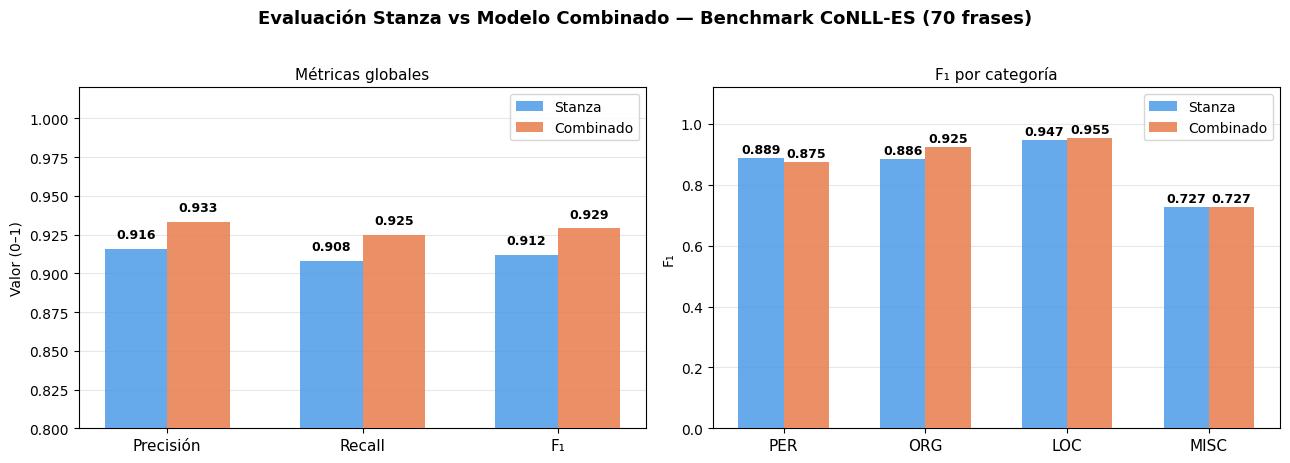

Guardado: resultados_globales.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Evaluación Stanza vs Modelo Combinado — Benchmark CoNLL-ES (70 frases)",
             fontsize=13, fontweight="bold", y=1.02)

# ── Gráfica izquierda: P / R / F1 global ────────────────────────────────────
ax = axes[0]
metricas = ["P", "R", "F1"]
vals_s = [r_s["global"][m] for m in metricas]
vals_e = [r_e["global"][m] for m in metricas]
x = np.arange(len(metricas))
w = 0.32

b1 = ax.bar(x - w/2, vals_s, w, label="Stanza",   color="#4C9BE8", alpha=0.85, zorder=3)
b2 = ax.bar(x + w/2, vals_e, w, label="Combinado", color="#E87C4C", alpha=0.85, zorder=3)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylim(0.80, 1.02)
ax.set_xticks(x); ax.set_xticklabels(["Precisión", "Recall", "F₁"], fontsize=11)
ax.set_title("Métricas globales", fontsize=11)
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_ylabel("Valor (0–1)")

# ── Gráfica derecha: F1 por categoría ───────────────────────────────────────
ax2 = axes[1]
cats = ENT_TYPES
f1_s = [r_s["per_type"][t]["F1"] for t in cats]
f1_e = [r_e["per_type"][t]["F1"] for t in cats]
x2   = np.arange(len(cats))

b3 = ax2.bar(x2 - w/2, f1_s, w, label="Stanza",   color="#4C9BE8", alpha=0.85, zorder=3)
b4 = ax2.bar(x2 + w/2, f1_e, w, label="Combinado", color="#E87C4C", alpha=0.85, zorder=3)

for bar in list(b3) + list(b4):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.set_ylim(0.0, 1.12)
ax2.set_xticks(x2); ax2.set_xticklabels(cats, fontsize=11)
ax2.set_title("F₁ por categoría", fontsize=11)
ax2.legend(fontsize=10); ax2.grid(axis="y", alpha=0.3, zorder=0)
ax2.set_ylabel("F₁")

plt.tight_layout()
plt.savefig("resultados_globales.png", dpi=140, bbox_inches="tight")
plt.show()
print("Guardado: resultados_globales.png")


## Desglose TP / FP / FN por categoría


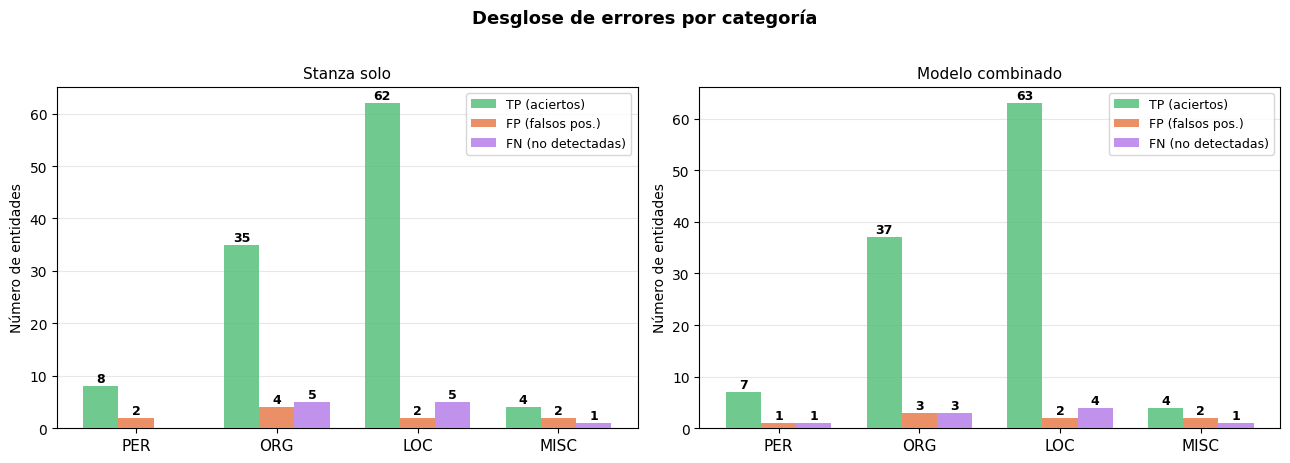

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
fig.suptitle("Desglose de errores por categoría", fontsize=13, fontweight="bold", y=1.02)

def plot_breakdown(ax, r, title):
    cats  = ENT_TYPES
    tps   = [r["per_type"][t]["TP"] for t in cats]
    fps   = [r["per_type"][t]["FP"] for t in cats]
    fns   = [r["per_type"][t]["FN"] for t in cats]
    x     = np.arange(len(cats))
    w     = 0.25
    ax.bar(x - w,  tps, w, label="TP (aciertos)",  color="#57C17B", alpha=0.85, zorder=3)
    ax.bar(x,      fps, w, label="FP (falsos pos.)", color="#E87C4C", alpha=0.85, zorder=3)
    ax.bar(x + w,  fns, w, label="FN (no detectadas)", color="#B57FE8", alpha=0.85, zorder=3)
    for bars in [ax.containers[0], ax.containers[1], ax.containers[2]]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x()+bar.get_width()/2, h+0.2, str(int(h)),
                        ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.set_ylabel("Número de entidades")

plot_breakdown(axes[0], r_s, "Stanza solo")
plot_breakdown(axes[1], r_e, "Modelo combinado")

plt.tight_layout()
plt.savefig("desglose_errores.png", dpi=140, bbox_inches="tight")
plt.show()


## Perfil de precisión/recall por categoría (radar)


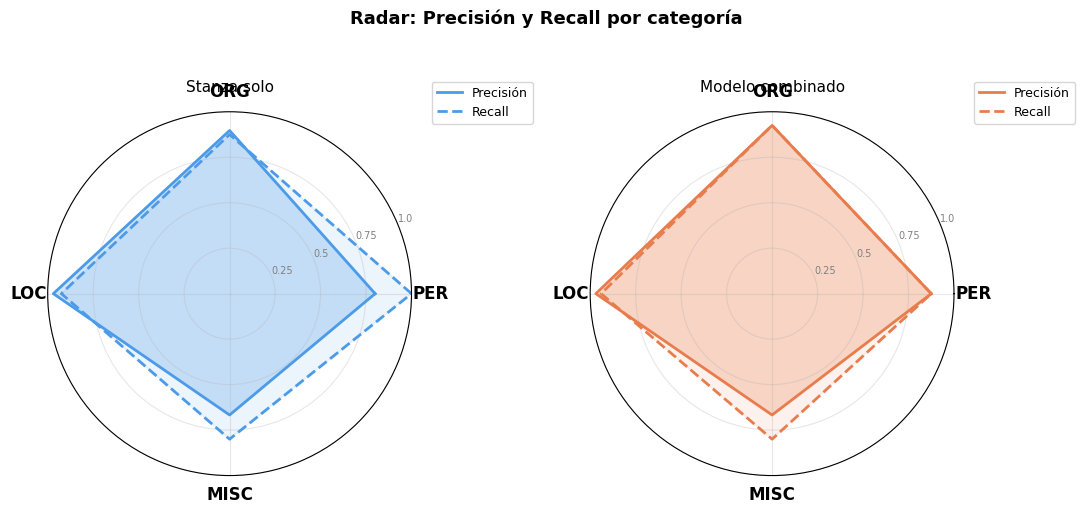

In [10]:
import numpy as np
import matplotlib.pyplot as plt

cats   = ENT_TYPES
N      = len(cats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # cerrar el polígono

def get_vals(r, metric):
    vals = [r["per_type"][t][metric] for t in cats]
    return vals + vals[:1]

fig, axes = plt.subplots(1, 2, figsize=(11, 5), subplot_kw=dict(polar=True))
fig.suptitle("Radar: Precisión y Recall por categoría", fontsize=13, fontweight="bold", y=1.03)

for ax, (r, title, color) in zip(axes, [
    (r_s, "Stanza solo",       "#4C9BE8"),
    (r_e, "Modelo combinado",  "#E87C4C"),
]):
    for metric, ls, alpha in [("P", "-", 0.25), ("R", "--", 0.1)]:
        vals = get_vals(r, metric)
        ax.plot(angles, vals, ls, color=color, linewidth=2,
                label=f"{'Precisión' if metric=='P' else 'Recall'}")
        ax.fill(angles, vals, color=color, alpha=alpha)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25","0.5","0.75","1.0"], fontsize=7, color="gray")
    ax.set_title(title, fontsize=11, pad=14)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("radar_categorias.png", dpi=140, bbox_inches="tight")
plt.show()


## Diferencias entre Stanza y el combinado


In [11]:
print(f"{'sid':>4} {'texto':30s} {'Stanza':8s} {'Combinado':10s} {'regla'}")
print("-" * 82)
diffs = []
for sid in sorted(GOLD):
    s_map = {e.text: e for e in preds_s.get(sid, [])}
    e_map = {e.text: e for e in preds_e.get(sid, [])}
    for txt in sorted(set(s_map)|set(e_map)):
        sl = s_map[txt].label if txt in s_map else "—"
        el = e_map[txt].label if txt in e_map else "—"
        rule = getattr(e_map.get(txt), "rule", "") or ""
        if sl != el:
            diffs.append((sid, txt, sl, el, rule))
            print(f"{sid:>4} {txt[:30]:30s} {sl:<8} {el:<10} {rule}")
print(f"\nTotal diferencias: {len(diffs)}")


 sid texto                          Stanza   Combinado  regla
----------------------------------------------------------------------------------
   0 Roche                          PER      ORG        xlm_ORG_corrige_stanza
  15 Casa Blanca                    ORG      LOC        xlm_LOC_corrige_ORG_de_stanza
  19 Al Nassr                       LOC      ORG        xlm_ORG_corrige_stanza
  20 Bernabéu                       ORG      LOC        xlm_LOC_corrige_ORG_de_stanza
  28 Estados Unidos                 ORG      LOC        xlm_LOC_corrige_ORG_de_stanza
  51 Hospital Gregorio Marañón      ORG      LOC        xlm_LOC_corrige_ORG_de_stanza
  52 Museo Guggenheim               ORG      LOC        xlm_LOC_corrige_ORG_de_stanza
  62 Bad Bunny                      PER      ORG        xlm_ORG_corrige_stanza

Total diferencias: 8


## Correcciones del ensamble: qué regla actuó y sobre qué entidades


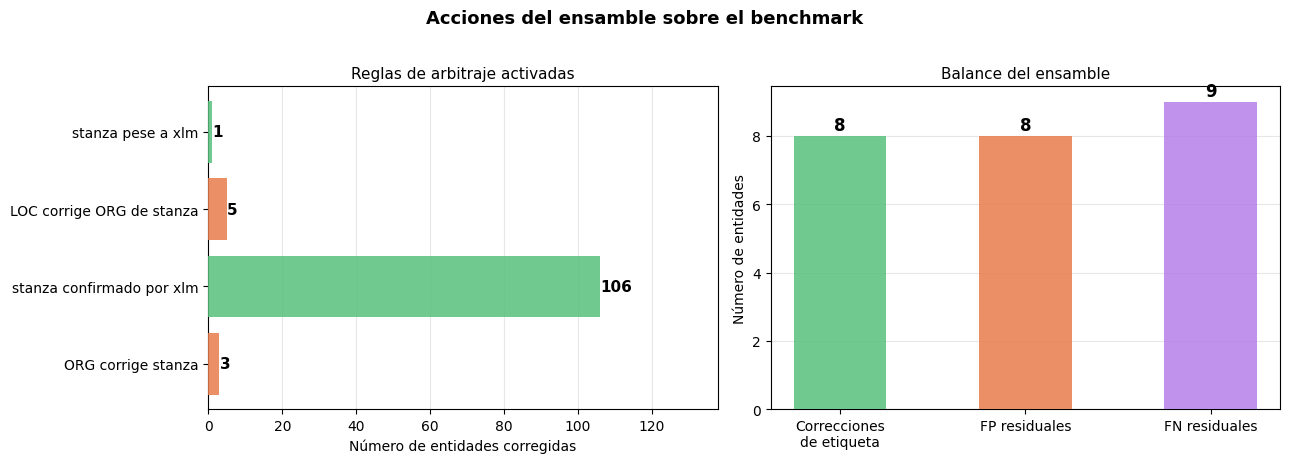

In [12]:
from collections import Counter

reglas = Counter()
for ents in preds_e.values():
    for e in ents:
        if e.rule and "xlm" in e.rule:
            reglas[e.rule] += 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Acciones del ensamble sobre el benchmark", fontsize=13,
             fontweight="bold", y=1.02)

# ── Izquierda: reglas aplicadas ───────────────────────────────────────────────
ax = axes[0]
labels_r = [r.replace("xlm_", "").replace("_", " ") for r in reglas]
vals_r   = list(reglas.values())
colors_r = ["#E87C4C" if "ORG" in l else "#57C17B" for l in labels_r]
bars = ax.barh(labels_r, vals_r, color=colors_r, alpha=0.85, zorder=3)
for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va="center", fontsize=11, fontweight="bold")
ax.set_xlabel("Número de entidades corregidas")
ax.set_title("Reglas de arbitraje activadas", fontsize=11)
ax.grid(axis="x", alpha=0.3, zorder=0)
ax.set_xlim(0, max(vals_r) * 1.3 if vals_r else 1)

# ── Derecha: entidades corregidas vs errores residuales ───────────────────────
ax2 = axes[1]
corregidas  = sum(1 for d in diffs if d[2] != "—" and d[3] != "—")
residuales  = len([e for e in r_e["errors"] if e["tipo"] == "FP"])
no_detect   = len([e for e in r_e["errors"] if e["tipo"] == "FN"])
categorias  = ["Correcciones\nde etiqueta", "FP residuales", "FN residuales"]
valores     = [corregidas, residuales, no_detect]
colores2    = ["#57C17B", "#E87C4C", "#B57FE8"]
bars2 = ax2.bar(categorias, valores, color=colores2, alpha=0.85, zorder=3, width=0.5)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(int(bar.get_height())), ha="center", va="bottom",
             fontsize=12, fontweight="bold")
ax2.set_title("Balance del ensamble", fontsize=11)
ax2.set_ylabel("Número de entidades"); ax2.grid(axis="y", alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig("correcciones_ensamble.png", dpi=140, bbox_inches="tight")
plt.show()


## Errores residuales del ensamble


In [13]:
fps = [e for e in r_e["errors"] if e["tipo"] == "FP"]
fns = [e for e in r_e["errors"] if e["tipo"] == "FN"]

print(f"=== Falsos positivos ({len(fps)}) — predicciones que no están en el gold ===")
print(f"{'sid':>4} {'texto':30s} {'pred':6s} {'gold (si corresponde)':22s} {'regla'}")
print("-" * 80)
for e in fps:
    print(f"{e['sid']:>4} {e['texto'][:30]:30s} {e['pred']:<6} {e['gold']:<22} {e['rule']}")

print(f"\n=== Falsos negativos ({len(fns)}) — entidades del gold no detectadas ===")
print(f"{'sid':>4} {'texto':30s} {'gold':6s}")
print("-" * 44)
for e in fns:
    print(f"{e['sid']:>4} {e['texto'][:30]:30s} {e['gold']}")


=== Falsos positivos (8) — predicciones que no están en el gold ===
 sid texto                          pred   gold (si corresponde)  regla
--------------------------------------------------------------------------------
   8 Juegos Olímpicos de Tokio      MISC   —                      stanza_solo
  11 Tribunal Supremo de Madrid     ORG    —                      stanza_solo
  31 Oscar                          PER    MISC                   stanza_pese_a_xlm
  46 Campos Elíseos de París        LOC    —                      stanza_solo
  50 Senado de Roma                 ORG    —                      stanza_confirmado_por_xlm
  51 Hospital Gregorio Marañón      LOC    —                      xlm_LOC_corrige_ORG_de_stanza
  62 Bad Bunny                      ORG    PER                    xlm_ORG_corrige_stanza
  69 G7                             MISC   —                      stanza_confirmado_por_xlm

=== Falsos negativos (9) — entidades del gold no detectadas ===
 sid texto                 

## Inspección frase a frase

Modifica `sids_a_ver` para explorar cualquier frase.


In [14]:
def inspeccionar(sid):
    frase = FRASES[sid]
    gold  = GOLD.get(sid, [])
    se    = preds_s.get(sid, [])
    ee    = preds_e.get(sid, [])
    print(f"\n{'─'*70}")
    print(f"SID {sid}: {frase}")
    print(f"  GOLD:      {[(g['text'], g['labels']) for g in gold]}")
    print(f"  Stanza:    {[(e.text, e.label) for e in se]}")
    print(f"  Ensamble:  {[(e.text, e.label, e.rule) for e in ee]}")

# Casos clave del TFG: Roche(0), Al Nassr(19), Bernabéu(20),
#                     Estados Unidos(28), G20(57), Ferrari(58)
sids_a_ver = [0, 19, 20, 28, 57, 58]
for sid in sids_a_ver:
    inspeccionar(sid)



──────────────────────────────────────────────────────────────────────
SID 0: Roche ha anunciado un nuevo fármaco producido en Suiza.
  GOLD:      [('Roche', ['ORG']), ('Suiza', ['LOC'])]
  Stanza:    [('Roche', 'PER'), ('Suiza', 'LOC')]
  Ensamble:  [('Roche', 'ORG', 'xlm_ORG_corrige_stanza'), ('Suiza', 'LOC', 'stanza_confirmado_por_xlm')]

──────────────────────────────────────────────────────────────────────
SID 19: Cristiano Ronaldo milita en el Al Nassr.
  GOLD:      [('Cristiano Ronaldo', ['PER']), ('Al Nassr', ['ORG'])]
  Stanza:    [('Cristiano Ronaldo', 'PER'), ('Al Nassr', 'LOC')]
  Ensamble:  [('Cristiano Ronaldo', 'PER', 'stanza_confirmado_por_xlm'), ('Al Nassr', 'ORG', 'xlm_ORG_corrige_stanza')]

──────────────────────────────────────────────────────────────────────
SID 20: El Real Madrid jugará en el Bernabéu.
  GOLD:      [('Real Madrid', ['ORG']), ('Bernabéu', ['LOC', 'ORG'])]
  Stanza:    [('Real Madrid', 'ORG'), ('Bernabéu', 'ORG')]
  Ensamble:  [('Real Madrid', 'ORG

## Resumen ejecutivo


In [15]:
gs, ge = r_s["global"], r_e["global"]

print("=" * 60)
print("  RESUMEN EJECUTIVO")
print("=" * 60)
print(f"  Gold: {sum(len(v) for v in GOLD.values())} entidades / {len(GOLD)} frases")
print()
print(f"  {'Modelo':<28} {'TP':>4} {'FP':>4} {'FN':>4}  {'P':>6} {'R':>6} {'F1':>6}")
print(f"  {'-'*56}")
for label, g in [("Stanza solo", gs), ("Combinado (Stanza+XLM)", ge)]:
    print(f"  {label:<28} {g['TP']:>4} {g['FP']:>4} {g['FN']:>4}  "
          f"{g['P']:>6.3f} {g['R']:>6.3f} {g['F1']:>6.3f}")
print()
print(f"  ΔF1 = {ge['F1']-gs['F1']:+.3f}  "
      f"({'↑ mejora' if ge['F1']>gs['F1'] else '= sin cambio' if ge['F1']==gs['F1'] else '↓ regresión'})")

print("\n  Reglas activadas por el ensamble:")
all_rules = Counter()
for ents in preds_e.values():
    for e in ents:
        if e.rule: all_rules[e.rule] += 1
for rule, n in sorted(all_rules.items(), key=lambda x: -x[1]):
    print(f"    {rule:<45} {n:>3} veces")


  RESUMEN EJECUTIVO
  Gold: 120 entidades / 70 frases

  Modelo                         TP   FP   FN       P      R     F1
  --------------------------------------------------------
  Stanza solo                   109   10   11   0.916  0.908  0.912
  Combinado (Stanza+XLM)        111    8    9   0.933  0.925  0.929

  ΔF1 = +0.017  (↑ mejora)

  Reglas activadas por el ensamble:
    stanza_confirmado_por_xlm                     106 veces
    xlm_LOC_corrige_ORG_de_stanza                   5 veces
    stanza_solo                                     4 veces
    xlm_ORG_corrige_stanza                          3 veces
    stanza_pese_a_xlm                               1 veces
